## Move and rename data

Below, script to convert from the old to the new data framework

In [1]:
from util import utilities as util
from util.data_loader import DataLoader
import pandas as pd
import os
import shutil
from tqdm import tqdm

# Define path to the original and the destination project folder
old_project_folder = r'E:\Cheeseboard-rawdata-editted_Stella_edit'
rawdata_folder = r'E:\cheeseboard-data\rawdata'
derivatives_folder = r'E:\cheeseboard-data\derivatives'

metadata = util.load_metadata()

In [6]:
for i in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[i])

    date_str = str(dl.date)
    old_date_formatted = f"{date_str[0:4]}-{date_str[4:6]}-{date_str[6:8]}"

    old_video_path = os.path.join(old_project_folder, old_date_formatted, 'movie',f"{old_date_formatted}_{dl.id}_trial_{dl.trial_id}.avi")
    new_video_path = dl.generate_filepath('video', 'rawdata', 'behav', 'avi')

    old_tracking_path = os.path.join(old_project_folder, old_date_formatted, 'movie','tracking',f"{old_date_formatted}_{dl.id}_trial_{dl.trial_id}_positions.csv")
    new_tracking_path = dl.generate_filepath('position', 'derivatives', 'behav', 'csv')

    old_trace_path = os.path.join(old_project_folder, old_date_formatted, 'movie','tracking',f"{old_date_formatted}_{dl.id}_trial_{dl.trial_id}_trace.png")
    new_trace_path = dl.generate_filepath('trace', 'derivatives', 'behav', 'png')

    old_loc_path = os.path.join(old_project_folder, old_date_formatted, "locations.csv")
    new_loc_path = dl.generate_filepath('triggerLoc', 'rawdata', 'behav', 'csv')
    loc = pd.read_csv(old_loc_path)
    loc = loc.rename(columns={
        'Animal': 'id',
        'Well_row': 'well_row',
        'Well_col': 'well_col',
        'Valence': 'valence',
    })
    loc = loc[loc['id'] == dl.id].reset_index(drop=True)

    if util.check_file_existence(old_video_path):
        os.makedirs(os.path.dirname(new_video_path), exist_ok=True)
        shutil.copy2(old_video_path, new_video_path)

    if util.check_file_existence(old_tracking_path):
        os.makedirs(os.path.dirname(new_tracking_path), exist_ok=True)
        shutil.copy2(old_tracking_path, new_tracking_path)
        
    if util.check_file_existence(old_trace_path):
        os.makedirs(os.path.dirname(new_trace_path), exist_ok=True)
        shutil.copy2(old_trace_path, new_trace_path)

    if util.check_file_existence(old_loc_path):
        os.makedirs(os.path.dirname(new_loc_path), exist_ok=True)
        loc.to_csv(new_loc_path, index=False)

 15%|█▍        | 596/4110 [03:08<15:41,  3.73it/s]

The file 'E:\Cheeseboard-rawdata-editted_Stella_edit\2025-06-28\movie\2025-06-28_AD_trial_11.avi' does not exist.


 20%|█▉        | 820/4110 [04:17<17:25,  3.15it/s]

The file 'E:\Cheeseboard-rawdata-editted_Stella_edit\2025-06-24\movie\tracking\2025-06-24_AF_trial_1_positions.csv' does not exist.
The file 'E:\Cheeseboard-rawdata-editted_Stella_edit\2025-06-24\movie\tracking\2025-06-24_AF_trial_1_trace.png' does not exist.


 31%|███       | 1258/4110 [06:27<15:27,  3.07it/s]

...

 55%|█████▌    | 2264/4110 [11:56<08:33,  3.60it/s]

The file 'E:\Cheeseboard-rawdata-editted_Stella_edit\2025-10-06\movie\tracking\2025-10-06_AO_trial_8_trace.png' does not exist.


 76%|███████▌  | 3122/4110 [15:51<03:42,  4.45it/s]

The file 'E:\Cheeseboard-rawdata-editted_Stella_edit\2024-12-01\movie\tracking\2024-12-01_I_trial_3_positions.csv' does not exist.
The file 'E:\Cheeseboard-rawdata-editted_Stella_edit\2024-12-01\movie\tracking\2024-12-01_I_trial_3_trace.png' does not exist.


100%|██████████| 4110/4110 [20:18<00:00,  3.37it/s]


## Code for reorganizing the metadata (depricated)


In [ ]:
# import pandas as pd

# # Define path to csv files with animal trial-sessions information
# genotypes_info_path = r'E:\cheeseboard-data\genotypes_Stella.csv'
# trials_info_path = r'E:\cheeseboard-data\trial_data_Stella.csv'

# # Read trials_info
# trials_info = pd.read_csv(trials_info_path)

# genotypes_info = pd.read_csv(genotypes_info_path)
# # Reorder columns
# genotypes_info = genotypes_info[['sub', 'id', 'genotype', 'test_order', 'remapping', 'short_duration', 'LFP', 'note']]
# # Order rows by sub
# genotypes_info = genotypes_info.sort_values(by="sub").reset_index(drop=True)
# # Save genotypes_info to a new csv file
# genotypes_info.to_csv(r'E:\cheeseboard-data\genotype_info_20251101.csv', index=False)

# trials_info = trials_info.merge(
#     genotypes_info[["id", "sub"]],
#     on="id",
#     how="left"
# )

# trials_info = trials_info[['sub', 'id' , 'date', 'trial_id', 'trial_type', 'trial_type_day', 'test_type', 'usable', 'note']]
# trials_info['date'] = pd.to_datetime(trials_info['date'], dayfirst=True, errors='coerce').dt.strftime('%Y%m%d')

# trials_info = trials_info.sort_values(by=['sub', 'date', 'trial_id']).reset_index(drop=True)

# trials_info.to_csv(r'E:\cheeseboard-data\trials_info_20251101.csv', index=False)

Add session id to the metadata

In [ ]:
# from util import utilities as util

# metadata = util.load_metadata('trials')
# metadata["ses"] = (
#     metadata.sort_values(["sub", "date"])
#     .groupby("sub")["date"]
#     .rank(method="dense")
#     .astype(int)
# )
# metadata = metadata[['sub', 'id', 'date', 'ses', 'trial_id', 'trial_type', 'trial_type_day','test_type', 'usable', 'trial_note']]
# metadata.to_csv(r'E:\cheeseboard-data\trials_info_20251101.csv', index=False)

## Test the new functions

In [1]:
from util.data_loader import DataLoader
import util.utilities as util
import numpy as np

metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[100])
position = dl.get_data('position')
x_loc = position['smooth_trans_x'].values
y_loc = position['smooth_trans_y'].values
in_roi = position['inside_roi'].values
x_loc[x_loc == -1] = np.nan
y_loc[y_loc == -1] = np.nan

cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [2]:
well_coords = []
for i in range(len(triggerLoc)):
    cheeseboardMap_loc = cheeseboardMap[(cheeseboardMap['well_row'] == triggerLoc['well_row'].values[i]) & (cheeseboardMap['well_col'] == triggerLoc['well_col'].values[i])]
    well_coords.append((cheeseboardMap_loc['trans_X'].values[0], cheeseboardMap_loc['trans_Y'].values[0]))

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

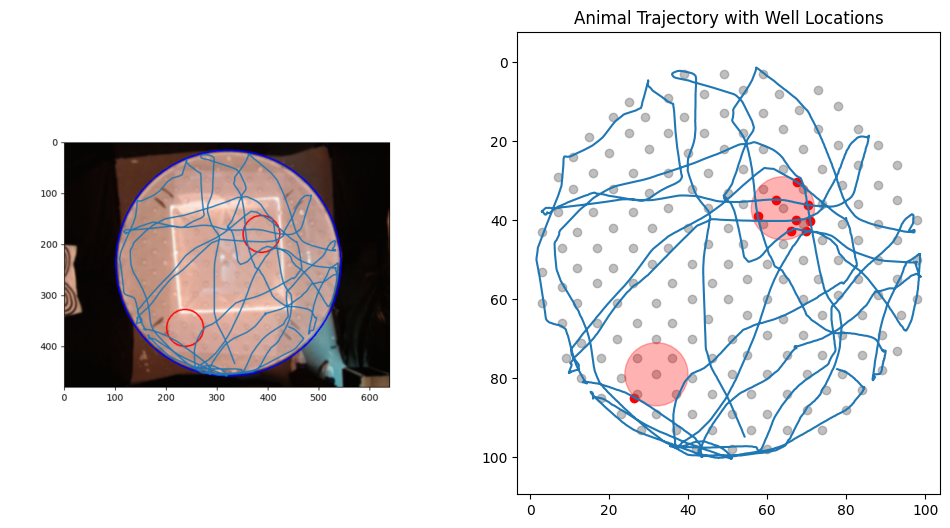

In [21]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(x_loc, y_loc)
axes[1].scatter(x_loc[in_roi], y_loc[in_roi], color='r')
axes[1].scatter(cheeseboardMap['trans_X'].values, cheeseboardMap['trans_Y'].values, alpha=0.5, color='gray')
for i in range(len(well_coords)):
    circle = plt.Circle((well_coords[i][0], well_coords[i][1]), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [36]:
def compute_well_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return {'time_to_arrive_zone': time_to_arrive_zone,
             'fraction_time_in_well': fraction_time_in_well,
             'num_crossings': num_crossings}